# Roll equations for high-powered rockets

Author  
Bruno Abdulklech Sorban,

Author  
Mateus Stano Junqueira

Date  
February 2022

## Nomenclature

-   $A_{r}$ - Reference area
-   $(C_{N\alpha})_{0}$ - Normal force coefficient derivative of a 2D
    airfoil
-   $(C_{N\alpha})_{1}$ - Normal force coefficient derivative of one fin
-   $C_r$ - Root chord
-   $C_t$ - Tip Chord
-   $F$ - Force
-   $L_{r}$ - Reference length, rocket diameter
-   $M_{roll}$ - Roll moment
-   $M_{f}$ - Roll forcing moment
-   $M_{d}$ - Roll damping moment
-   $N$ - Number of fins
-   $\overline{q}$ - Dynamic pressure
-   $r_t$ - Reference radius at fins position
-   $s$ - Span
-   $v_{0}$ - Rocket speed in relation to the wind
-   $\omega$ - Angular velocity
-   $Y_{MA}$ - Spanwise location of mean aerodynamic chord measured from
    the root chord
-   $\delta$ - Fin cant angle
-   $\xi$ - Distance to rotation axis
-   $\rho$ - Ambient density
-   $C_{lf}$ - Roll moment lift coefficient
-   $C_{lf\delta}$ - Roll moment lift coefficient derivative
-   $C_{ld}$ - Roll moment damping coefficient
-   $C_{ld\omega}$ - Roll moment damping coefficient derivative

## Introduction

Calculating the rotational movement of a high powered rocket entails
calculating the **Roll Moment**. Here all formulas and consideration for
the implementation of the Roll Moment on **RocketPy** are shown and
explained.

The main cause for a rocket roll movement are certain asymmetries in its
construction. The most noteworthy of this possible asymmetries is the
fin cant angle ($\delta$), which can be seen in the next Figure and will
be considered for the calculations.

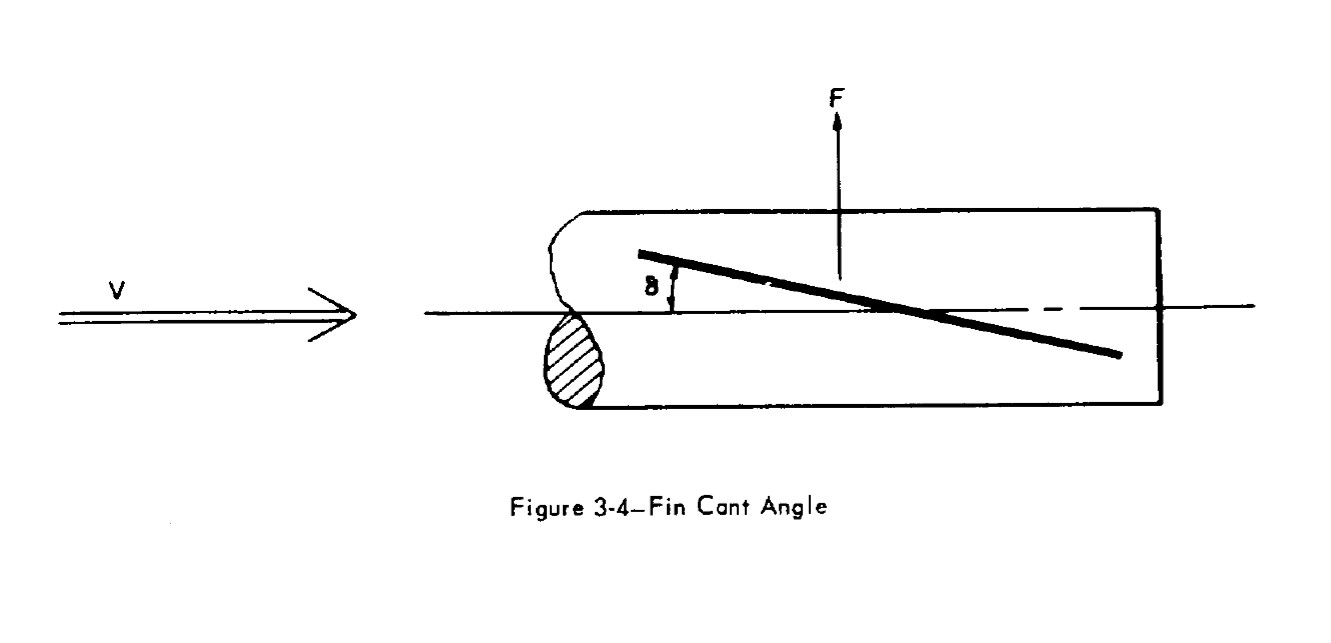

## Coefficient derivatives

According to the equation formulated by [\[Barrowman\]](), the
rotational moment around the rockets axis is governed by two main
forces: one that causes the rolling movement and one that damps the
movement. Each of these forces generates its own moment, the forcing
moment $M_{f}$ and the damping moment $M_{d}$. The final roll moment can
then be calculated with:

$$M_{roll} = M_{forcing} - M_{damping}$$

### Roll Forcing

*Roll forcing* is the moment that causes the rocket to rotate around its
axis. The calculations for this moment assumes $\omega = 0$ e
$\delta \neq 0$.

Due to the symmetry of the fins - as can be seen in the Figure below -
the forces cancel each other out so that the resulting force $F_{R}$ is
equal to zero. However, the resulting moment $M_{R} \neq 0$, that is, it
constitutes a gyroscope binary.

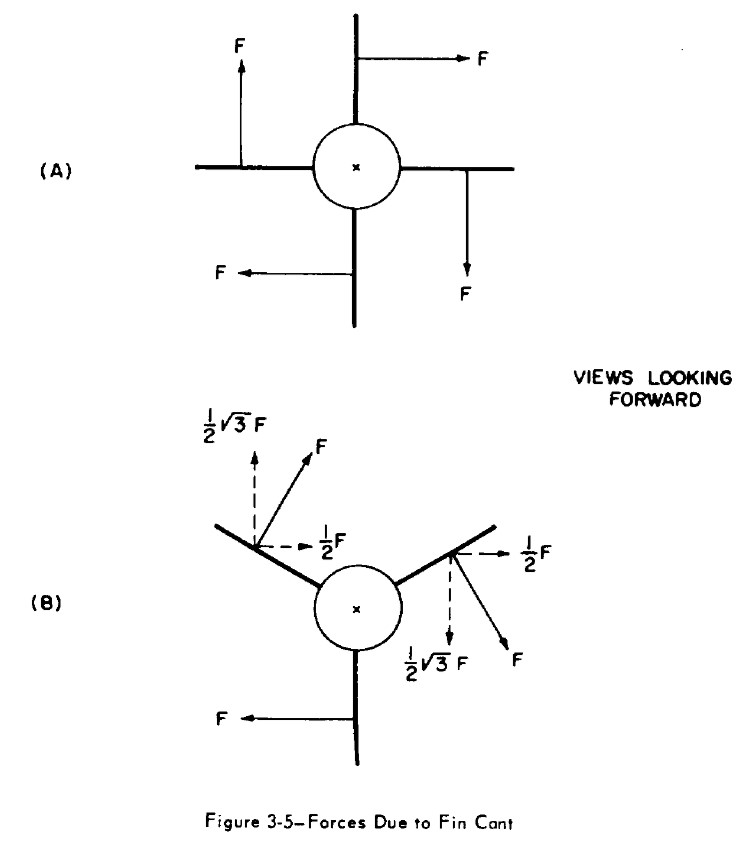

According to [\[Barrowman\]](), equation (3-31), the roll forcing moment
is given by:

$$M_f = N (Y_{MA} + r_t)(C_{N\alpha})_1\delta \overline{q}A_r$$

The author also defined the roll forcing moment coefficient as:

$$C_{lf} = \frac{M_f}{\overline{q} A_r L_r}$$

The letter $f$ has been added to the name to differentiate **Forcing**
from **Damping**. Note the similarity with the definition of drag
coefficient ($C_{d} = \frac{2F_{Drag}}{\rho V^2 A_{ref}}$). Finally, you
can also calculate $C_{lf}$ as:

$$C_{lf} = \frac{N(Y_{MA} + r_t)(C_{N\alpha})_1 \delta}{L_r}$$

And its derivative relative to the cant angle as:

$$C_{lf\delta} = \frac{\partial C_{lf}}{\partial \delta}$$

$$C_{lf\delta} = \frac{N (Y_{MA} + r_t) (C_{N\alpha})_1 }{L_r}$$

The forcing moment is then calculated with:

$$M_f =  \overline{q} \,\, A_r L_r  \,\, C_{lf\delta}\,\, \delta$$

or

$$M_f =  \frac{1}{2} \rho v_0^2 \,\, A_r L_r  \,\, C_{lf\delta}\,\, \delta$$

### Roll Damping

While roll forcing causes the rotation movement, the roll damping force
is what counteracts this movement. It is a force that scales with
angular velocity and acts in the opposite direction. $\omega \neq 0$ and
$\delta = 0$ are assumed.

It is defined in the same way as roll forcing:

<span id="9">$$C_{ld} = \frac{M_d}{\overline{q} A_r L_r}$$</span>

From [\[Barrowman\]](), the roll damping moment depends on the angle of
attack of the tangential velocity of the fin panel at a certain span
wise position $\xi$, as can be seen in the Figure below.

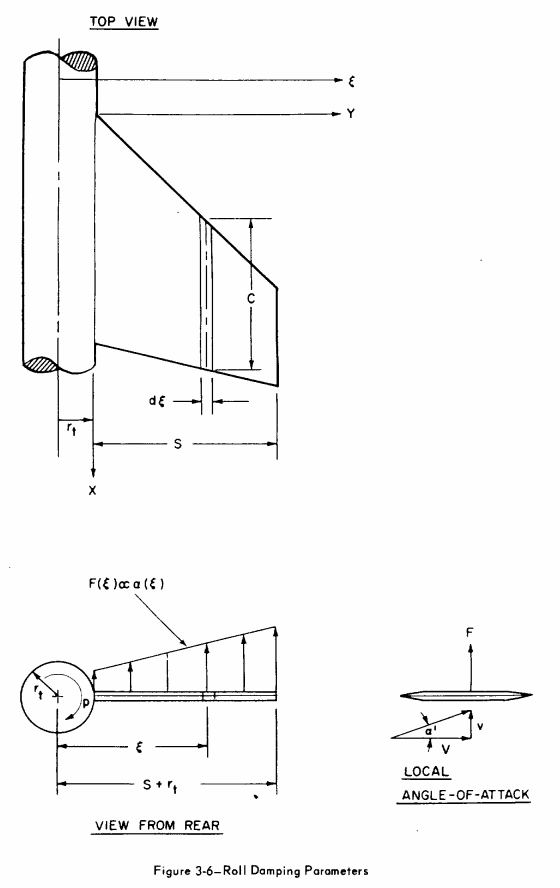

The damping moment at $\xi$ is:

$$d M = \xi F(\xi)$$

Where $F(\xi)$ is the force generated at the span wise position $\xi$
and its given by:

$$F(\xi) = - C_{N_{\alpha 0}} \, \overline{q} \, a(\xi) \,c(\xi) \, d\xi$$

$a(\xi)$ is the local angle of attack at $\xi$ and is given by:

$$a(\xi) = \tan^{-1}(\frac{\omega \, \xi}{v_0}    )$$

An approximation that is valid when $v_0 >> \omega \, \xi$ is made

$$a(\xi) = - \frac{\omega \, \xi}{v_0}$$

$c(\xi)$ is the cord length at the span wise $\xi$ and is calculated
differently for each fin shape. The damping moment can then be written
as:

$$dM = - \frac{C_{N_{\alpha 0}} \, \overline{q} \, \omega}{v_0} \,\, c(\xi) \,\xi^2 \,  d\xi$$

We know that:

$$d C_{ld} = \frac{C_{N_{\alpha 0}} \,  \, \omega}{v_0 \ A_r \, L_r} \,\, c(\xi) \,\xi^2 \, d\xi$$

Integrating over the exposed fin geometry:

$$C_{ld} = \frac{C_{N_{\alpha 0}} \,  \, \omega}{v_0 \ A_r \, L_r} \,\, \int_{r_t}^{s + r_t} c(\xi) \, \xi^2 \, d\xi$$

The initial hypothesis assumes that, for the roll damping calculation,
the deflection is $\delta = 0$. This implies a larger cross-sectional
area than is actually acting against the movement (analogous to flow
passing through a surface). As a result, the term $\cos(\delta)$ was
added to the original formulation:

$$C_{ld} = \frac{C_{N_{\alpha 0}} \,  \, \omega}{v_0 \ A_r \, L_r} \, \cos(\delta) \, \int_{r_t}^{s + r_t} c(\xi) \, \xi^2 \, d\xi$$

The roll damping coefficient derivative can then be defined as:

$$C_{ld\omega} = \frac{\partial C_{ld}}{\partial (\frac{\omega L_{r}}{2v_0})}$$

$$C_{ld\omega} = \frac{2 \ C_{N_{\alpha 0}} \,  }{A_r \, L_r^2} \, \cos(\delta) \, \int_{r_t}^{s + r_t} c(\xi) \, \xi^2 \,d\xi$$

Finally, $C_{N_{\alpha 0}}$ must be corrected for three dimensional
effects:

$$C_{ld\omega} = \frac{2 \ N\ \Bigl(C_{N_{\alpha }}\Bigr)_1 \,  }{A_r \, L_r^2} \, \cos(\delta) \, \int_{r_t}^{s + r_t} c(\xi) \, \xi^2 \,d\xi$$

The values of the definite integral can be calculated for each specific
fin shape. For trapezoidal fins:

$$c(\xi) = C_r \left[1 - \frac{1 - \frac{C_t}{C_r}}{s}(\xi - r_t)\right]$$

$$\int_{r_t}^{s + r_t} c(\xi) \, \xi^2 \, d\xi = \frac{s}{12} \left[(C_r + 3C_t) s^2 + 4(C_r + 2C_t)s r_t + 6(C_r+C_t)r_t^2 \right]$$

And for ellipsoidal fins:

$$c(\xi) = C_r \sqrt{1 - \Bigl(\frac{\xi - r_t}{s}\Bigr)^2}$$

$$\int_{r_t}^{s + r_t} c(\xi) \, \xi^2 \, d\xi = C_r\, s\ \frac{ \Bigl(3\pi s^2 + 32 r_t s + 12 \pi r_t^2 \Bigr)}{48}$$

The damping moment is finally:

$$M_d = \frac{1}{2} \rho v_0^2 \ A_{ref} \, L_{ref} \ C_{ld\omega} \, \frac{\omega L_{ref}}{2 v_0}$$

## Interference Coefficients

In [\[Barrowman\]]() some fin-body interference factor are calculated.
These factors are also implemented in the lift coefficient calculations.

For fins with canted angle:

$$\begin{aligned}
K_f &=\frac{1}{\pi^{2}}\left[\frac{\pi^2}{4}\frac{(\tau+1)^{2}}{\tau^2}+\frac{\pi\Bigl(\tau^{2}+1\Bigr)^{2}}{\tau^{2}(\tau-1)^{2}} \sin ^{-1}\Bigl(\frac{\tau^{2}-1}{\tau^{2}+1}\Bigr)-\frac{2 \pi(\tau+1)}{\tau(\tau-1)}\right.\\
&+\frac{\Bigl(\tau^{2}+1\Bigr)^{2}}{\tau^{2}(\tau-1)^{2}}\Bigl(\sin ^{-1} \frac{\tau^{2}-1}{\tau^{2}+1}\Bigr)^{2}-\frac{4(\tau+1)}{\tau(\tau-1)} \sin ^{-1}\Bigl(\frac{\tau^{2}-1}{\tau^{2}+1}\Bigr) \\
&\left.+\frac{8}{(\tau-1)^{2}} \ln \Bigl(\frac{\tau^{2}+1}{2 \tau}\Bigr)\right]
\end{aligned}$$

For the damping moment lift coefficient derivative:

$$K_d=1+\frac{\frac{\tau-\lambda}{\tau}-\frac{1-\lambda}{\tau-1} \ln \tau}{\frac{(\tau+1)(\tau-\lambda)}{2}-\frac{(1-\lambda)\Bigl(\tau^{3}-1\Bigr)}{3(\tau-1)}}$$

Where $\tau = \frac{s + r_t}{r_t}$ and $\lambda = \frac{C_t}{C_r}$. The
final lift coefficients are:

$$(C_{lf\delta})_{K_{f}} = K_{f} \cdot C_{lf\delta}$$

$$(C_{ld\omega})_{K_{d}} = K_{d} \cdot C_{ld\omega}$$

## Comments

Roll moment is expected to increase linearly with velocity. This
relationship can be verified in the rotation frequency equilibrium
equation, described by [\[Niskanen\]]() in equation (3.73), and again
stated below:

$$f_{eq} = \frac{\omega}{2\pi} = \frac{A_{ref}\beta \overline{Y_t} (C_{N\alpha})_1 }{4\pi^2 \sum_{i} c_i \xi^2 \Delta \xi} \, \delta V_0$$

The auxiliary value $\beta$ is defined as: $\beta = \sqrt{|1-M|}$, where
M is the speed of the rocket in Mach.